In [428]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import normalize

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [429]:
df = pd.read_csv(r"C:\Users\zaid9\Downloads\SHREECEM.NS_stock_data.csv")
print(df.head())

   Unnamed: 0       open       high        low      close   adjclose   volume  \
0  2001-07-02  29.750000  32.950001  29.750000  32.950001  27.455931     27.0   
1  2001-07-03  30.799999  31.350000  30.000000  30.500000  25.414442   5700.0   
2  2001-07-04  30.500000  31.000000  30.000000  30.900000  25.747747   4596.0   
3  2001-07-05  30.450001  31.500000  30.450001  31.500000  26.247704   7001.0   
4  2001-07-06  30.250000  31.200001  29.900000  30.299999  25.247793  13875.0   

        ticker  
0  SHREECEM.NS  
1  SHREECEM.NS  
2  SHREECEM.NS  
3  SHREECEM.NS  
4  SHREECEM.NS  


In [430]:
df["Date"] = pd.to_datetime(df["Unnamed: 0"])
df = df.sort_values("Date").reset_index(drop=True)

In [431]:
numeric_df=df.iloc[:,2:-1]

In [432]:
print(df.isnull().sum())
print(df.isnull().values.any())

Unnamed: 0     0
open          11
high          11
low           11
close         11
adjclose      11
volume        11
ticker         0
Date           0
dtype: int64
True


In [433]:
print(df.dtypes)

Unnamed: 0               str
open                 float64
high                 float64
low                  float64
close                float64
adjclose             float64
volume               float64
ticker                   str
Date          datetime64[us]
dtype: object


In [434]:
for col in df.columns:
    if col != "Date":
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [435]:
df = df.interpolate(method="linear")
df = df.ffill().bfill()

In [436]:
data = df[["close"]]

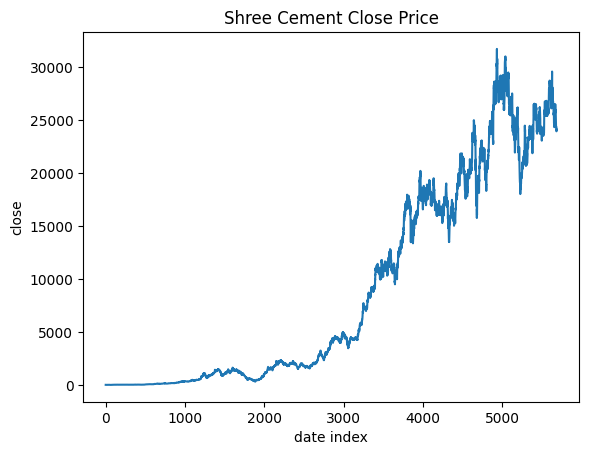

In [437]:
plt.plot(data)
plt.title("Shree Cement Close Price")
plt.xlabel("date index")
plt.ylabel("close")
plt.show()

In [438]:
data = data.values.astype(np.float32)

In [439]:
TRAIN_RATIO=0.8
INPUT_STEPS=10
OUTPUT_STEPS=1

In [440]:


split_idx = int(len(data) * TRAIN_RATIO)

train_data1 = data[:split_idx]
test_data = data[split_idx:]

val_split_idx = int(len(train_data1) * 0.8)

train_data = train_data1[:val_split_idx]
val_data = train_data1[val_split_idx:]

In [441]:
train_data.shape,test_data.shape,val_data.shape

((3640, 1), (1138, 1), (911, 1))

In [442]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

train_data = scaler.fit_transform(train_data)
val_data = scaler.transform(val_data)
test_data = scaler.transform(test_data)

In [443]:


def create_sequences(data,INPUT_STEPS,OUTPUT_STEPS):
    X, y = [], []


    for i in range(len(data)-INPUT_STEPS - OUTPUT_STEPS):
        X.append(data[i:i+INPUT_STEPS])
        y.append(data[i+INPUT_STEPS:i+INPUT_STEPS+OUTPUT_STEPS])

    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_data,INPUT_STEPS,OUTPUT_STEPS)
X_val, y_val = create_sequences(val_data,INPUT_STEPS,OUTPUT_STEPS)
X_test, y_test = create_sequences(test_data,INPUT_STEPS,OUTPUT_STEPS)

In [444]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [445]:
train_loader = DataLoader(TimeSeriesDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TimeSeriesDataset(X_val, y_val), batch_size=32,shuffle=False)
test_loader = DataLoader(TimeSeriesDataset(X_test, y_test), batch_size=32,shuffle=False)

In [446]:
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=100, batch_first=True)
        self.fc = nn.Linear( 100,1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out.unsqueeze(-1)

In [447]:
model = LSTMModel()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [448]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [449]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)

In [450]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(X_batch)
            loss = criterion(preds, y_batch)

            running_loss += loss.item() * X_batch.size(0)

            all_preds.append(preds.cpu())
            all_targets.append(y_batch.cpu())

    avg_loss = running_loss / len(loader.dataset)
    all_preds = torch.cat(all_preds, dim=0).numpy()
    all_targets = torch.cat(all_targets, dim=0).numpy()

    return avg_loss, all_preds, all_targets

In [451]:

EPOCHS = 30
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, _, _ = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

Epoch [1/30] | Train Loss: 0.008078 | Val Loss: 0.010950
Epoch [2/30] | Train Loss: 0.000143 | Val Loss: 0.014082
Epoch [3/30] | Train Loss: 0.000144 | Val Loss: 0.009999
Epoch [4/30] | Train Loss: 0.000153 | Val Loss: 0.021487
Epoch [5/30] | Train Loss: 0.000174 | Val Loss: 0.013863
Epoch [6/30] | Train Loss: 0.000170 | Val Loss: 0.013878
Epoch [7/30] | Train Loss: 0.000182 | Val Loss: 0.010689
Epoch [8/30] | Train Loss: 0.000154 | Val Loss: 0.009032
Epoch [9/30] | Train Loss: 0.000217 | Val Loss: 0.013296
Epoch [10/30] | Train Loss: 0.000164 | Val Loss: 0.007828
Epoch [11/30] | Train Loss: 0.000120 | Val Loss: 0.013948
Epoch [12/30] | Train Loss: 0.000155 | Val Loss: 0.011487
Epoch [13/30] | Train Loss: 0.000118 | Val Loss: 0.014605
Epoch [14/30] | Train Loss: 0.000137 | Val Loss: 0.008811
Epoch [15/30] | Train Loss: 0.000134 | Val Loss: 0.014210
Epoch [16/30] | Train Loss: 0.000119 | Val Loss: 0.008058
Epoch [17/30] | Train Loss: 0.000143 | Val Loss: 0.005409
Epoch [18/30] | Train L

In [452]:
EPOCHS = 6
PATIENCE = 5   

train_losses = []
val_losses = []

best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, _, _ = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0

    
        torch.save(model.state_dict(), "best_model.pt")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

Epoch [1/6] | Train Loss: 0.000096 | Val Loss: 0.004249
Epoch [2/6] | Train Loss: 0.000091 | Val Loss: 0.001883
Epoch [3/6] | Train Loss: 0.000083 | Val Loss: 0.007990
Epoch [4/6] | Train Loss: 0.000082 | Val Loss: 0.004769
Epoch [5/6] | Train Loss: 0.000079 | Val Loss: 0.002403
Epoch [6/6] | Train Loss: 0.000075 | Val Loss: 0.002949


In [453]:
test_loss, predictions, targets = evaluate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.6f}")

Test Loss: 0.033395


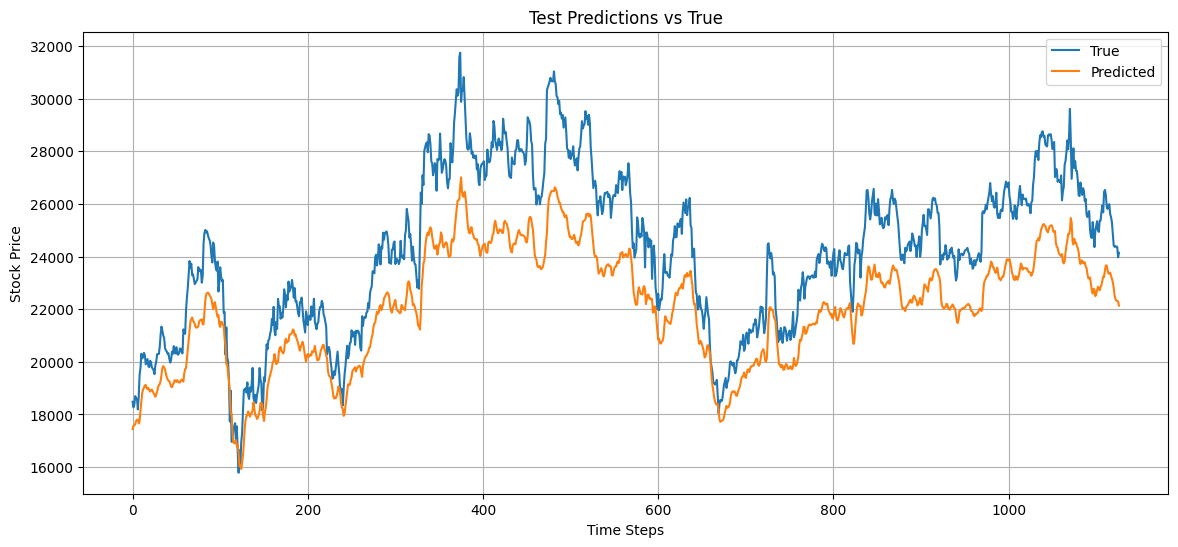

In [454]:
predictions_reshaped = predictions.reshape(-1, 1)
targets_reshaped = targets.reshape(-1, 1)

predictions_inv = scaler.inverse_transform(predictions_reshaped)
targets_inv = scaler.inverse_transform(targets_reshaped)

plt.figure(figsize=(14, 6))
plt.plot(targets_inv, label="True")
plt.plot(predictions_inv, label="Predicted")

plt.title("Test Predictions vs True")
plt.xlabel("Time Steps")
plt.ylabel("Stock Price")

plt.legend()
plt.grid(True)
plt.show()